<a href="https://colab.research.google.com/github/adrinorosario/legal-pragmatic-inference/blob/main/dataset_construction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Triplet Dataset Construction

The triplet dataset needs to have the following structure:

- A contractual clause
- Vague term(s)
- Judicial interpretation and reasoning


Illustrated workflow:

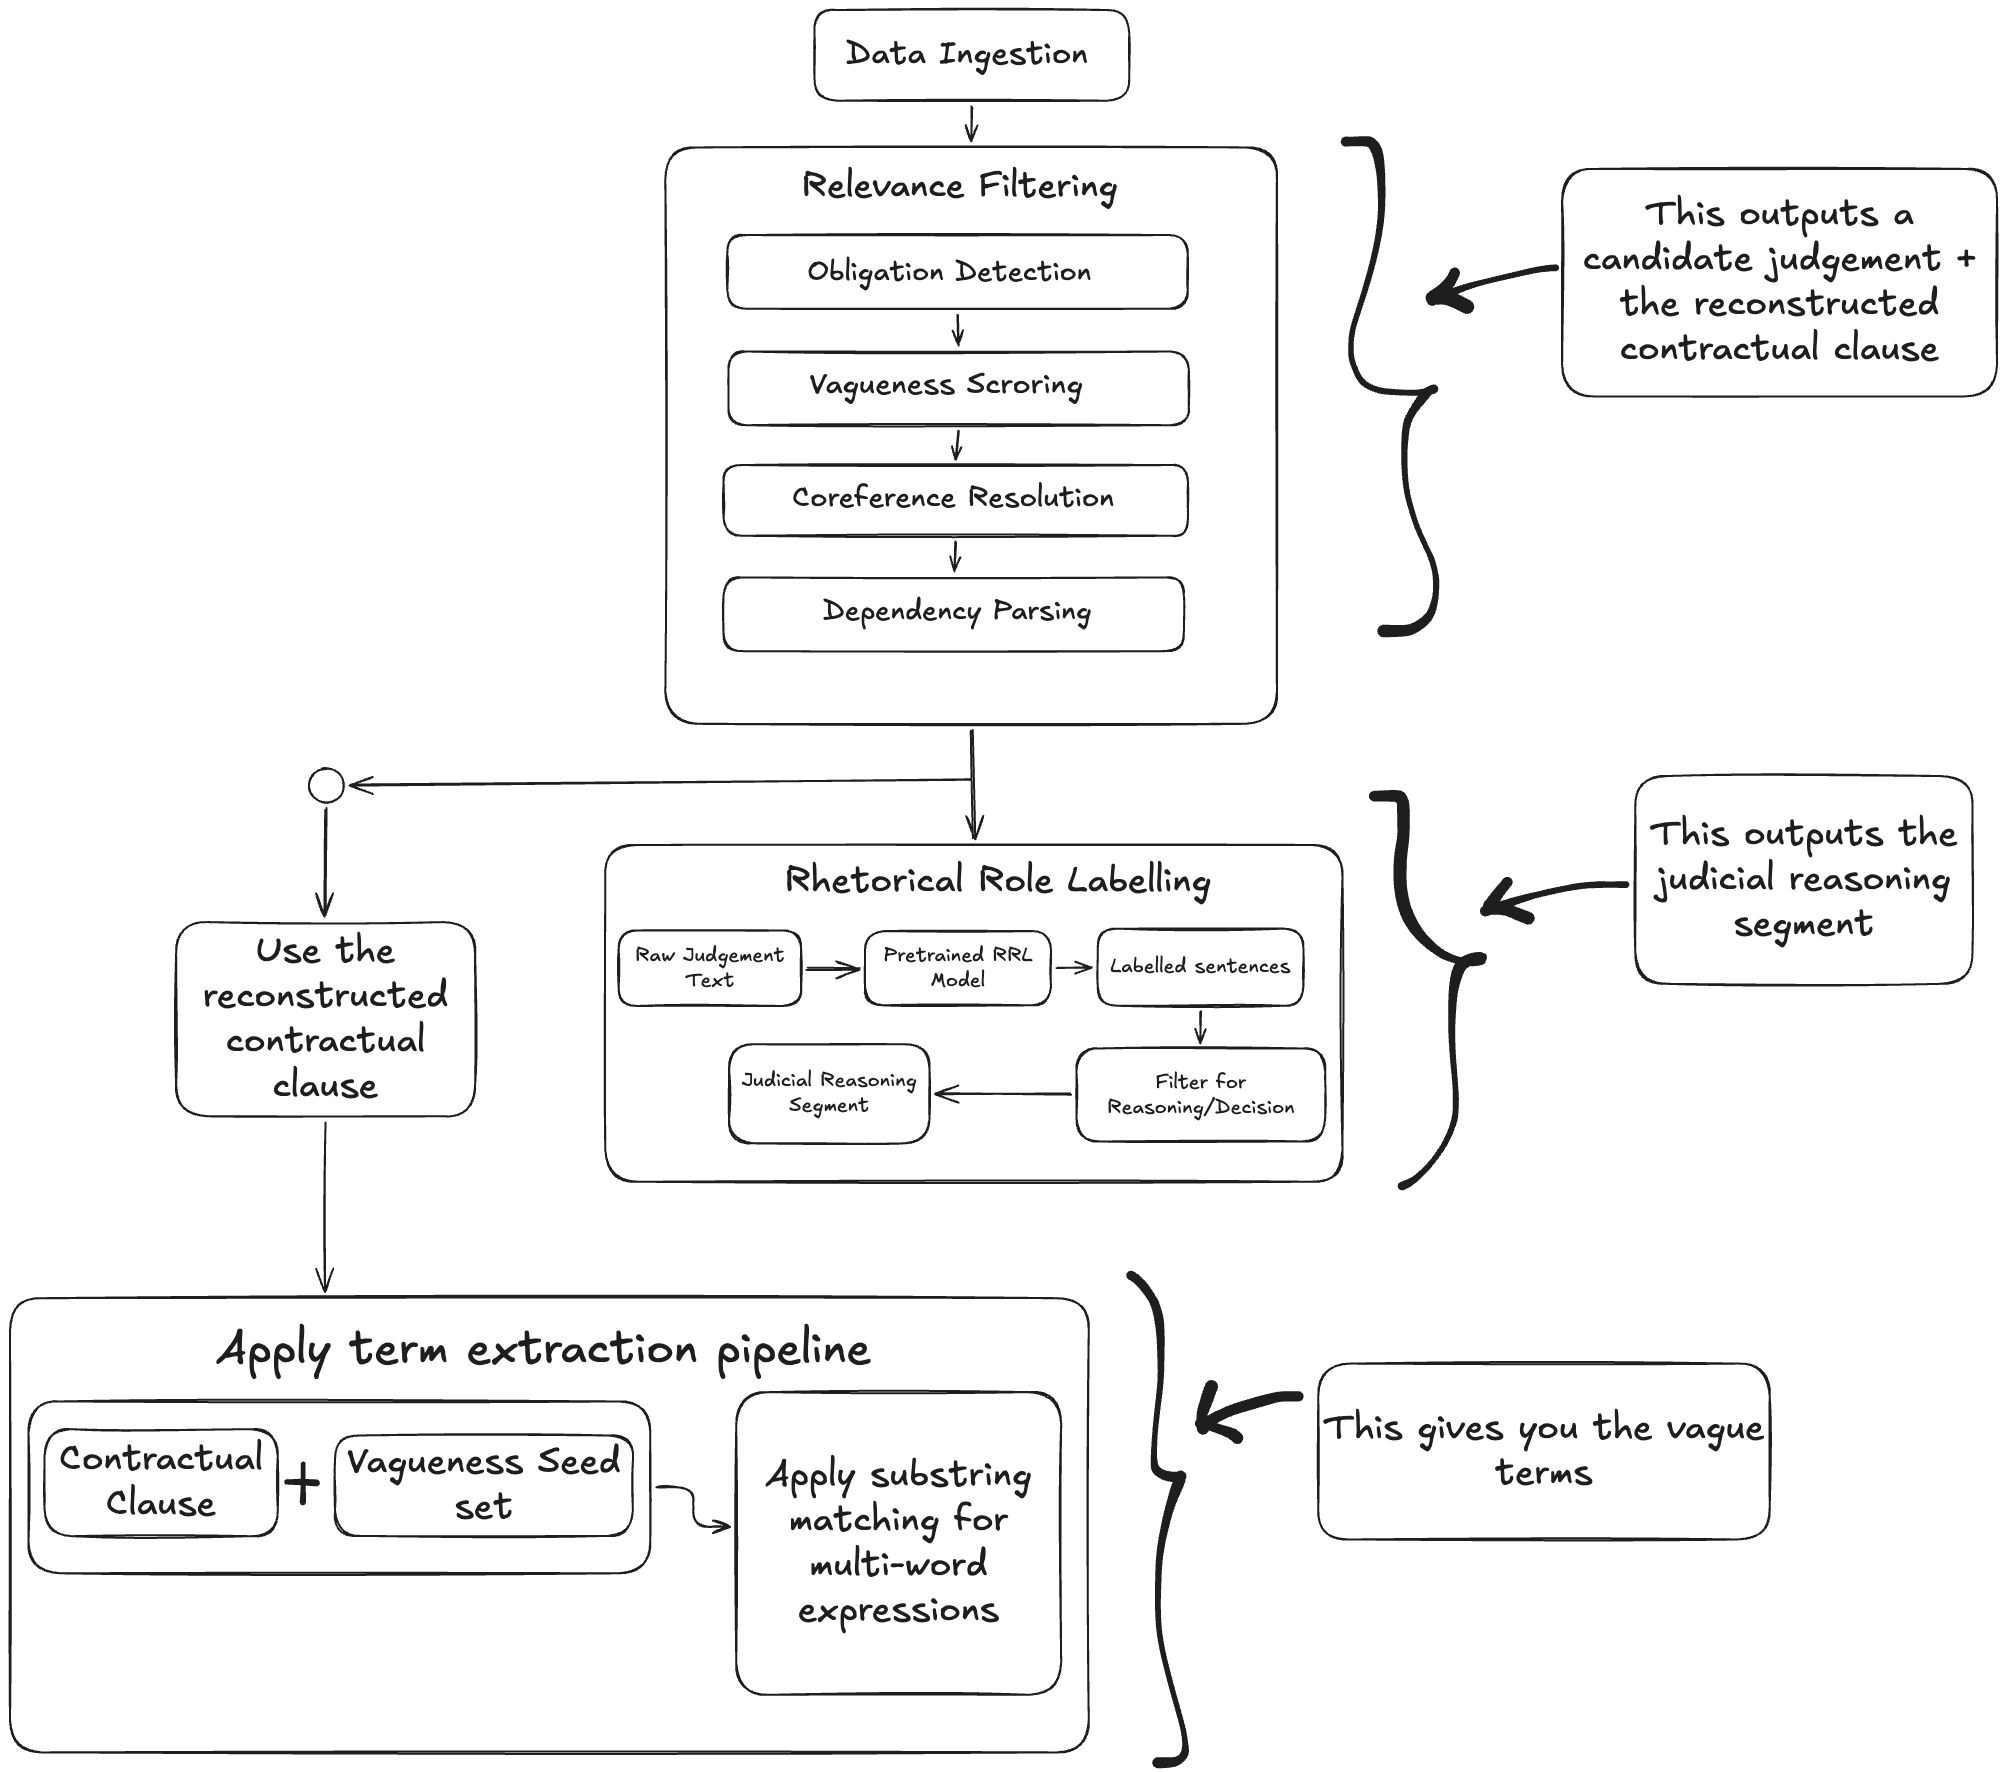

**Step-by-Step walkthrough**

1. Ingest the data. The legal documents/opinions
2. Detect if the input has an obligation (not vague legal obligation). Flag if it contains one or not.
    * If it does, apply ***Relevance Filtering*** to identify if they contain vague legal obligations (`relevance_filter()`)
    * Compute the probability of vagueness scoring (`score_vagueness()`)
    * Identify and isolate sentences that contain quoted contractual clauses (`detect_quoted_clauses()`)
    * Apply **coreference resolution** to identify and pickup the vague obligations leaked over to multiple sentences (`coreference_resolution()`)
    * Use the linked sentences and apply **dependency parsing** to reconstruct the clause (`dependency_parser()`)
3. Use the reconstructed clause, and apply substring matching with a vagueness seed set to extract the vague terms
4. Perform ***Rhetorical Role Labelling*** using a pretrained model. Extract the _decision_ and _reasoning_ chunks.
5. Use the outputs from step 2 (reconstructed contractual clause), step 3 (vague terms), and step 4 (judicial reasoning segment) to contruct the triplet form.

## Relevance Filtering

Given a particular judgement, we need to identify whether it contains a disputed vague obligation term or not.


1. ***Obligation detection:*** Leverage SparkNLP to flag whether a document/opinion contains a vague obligation term or not. Identify the Party + Modal verb + Action

## Environment Setup

Three install groups cover the full pipeline:

1. **SparkNLP stack** — `sparknlp` and `pyspark` for scalable NLP operations.
2. **Hugging Face** — dataset access via the `datasets` library and authenticated hub access via `huggingface_hub`.
3. **Sentence Transformers** — `sentence-transformers` for vagueness similarity scoring.

> ⚠️ The Hugging Face token is pulled from Kaggle secrets. Ensure `HF_READ_DATASETS_TOKEN` is set in your Kaggle secret store before running.

In [1]:
!pip install sparknlp
!pip install spark-nlp
!pip install pyspark

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 766.8/766.8 kB 11.2 MB/s eta 0:00:00


In [2]:
import numpy as np

In [3]:
import sparknlp
import os
from kaggle_secrets import UserSecretsClient

spark = sparknlp.start()
print(sparknlp.version())

user_secrets = UserSecretsClient()
hf_token = user_secrets.get_secret("HF_READ_DATASETS_TOKEN")

# Set it as an environment variable so Hugging Face libraries find it
os.environ["HF_READ_DATASETS_TOKEN"] = hf_token

# Verify login via huggingface_hub
from huggingface_hub import login
login(token=hf_token)


:: loading settings :: url = jar:file:/usr/local/lib/python3.12/dist-packages/pyspark/jars/ivy-2.5.3.jar!/org/apache/ivy/core/settings/ivysettings.xml
Ivy Default Cache set to: /root/.ivy2.5.2/cache
The jars for the packages stored in: /root/.ivy2.5.2/jars
com.johnsnowlabs.nlp#spark-nlp_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-080dd5f1-bcec-4c2d-a2e9-5dbc915f9c7b;1.0
	confs: [default]
	found com.johnsnowlabs.nlp#spark-nlp_2.12;6.4.0 in central
	found com.typesafe#config;1.4.2 in central
	found org.rocksdb#rocksdbjni;6.29.5 in central
	found com.amazonaws#aws-java-sdk-s3;1.12.500 in central
	found com.amazonaws#aws-java-sdk-kms;1.12.500 in central
	found com.amazonaws#aws-java-sdk-core;1.12.500 in central
	found commons-logging#commons-logging;1.1.3 in central
	found commons-codec#commons-codec;1.15 in central
	found org.apache.httpcomponents#httpclient;4.5.13 in central
	found org.apache.httpcomponents#httpcore;4.4.13 in central
	foun

6.4.0


## Data Loading — Harvard LIL Cold Cases

The dataset is streamed from Hugging Face to avoid loading the full corpus into memory. Only cases with `"contract"` in the `nature_of_suit` field are examined. The first three valid cases are printed as a sanity check.

> **Note:** Many cases tagged with "contract" also carry tort or real property claims. The `detect_obligations()` gate handles this — it filters on the presence of vague obligation language, not just the case type.

In [4]:
from datasets import load_dataset

# load the dataset from HuggingFace: https://huggingface.co/datasets/harvard-lil/cold-cases
dataset = load_dataset(
    "harvard-lil/cold-cases",
    split="train",
    streaming=True
)

# filter out the dataset to only read Contract cases and print the first 3 raw opinion texts
count = 0

for case in dataset:
    nature = case.get("nature_of_suit", "") or "" # read the nature of the case
    if "contract" in nature.lower():
        opinions = case.get("opinions", []) # extract the opinions into a list
        if opinions and opinions[0].get("opinion_text"):
            print(f"CASE: {case.get('case_name', "Unknown")}")
            print(f"COURT: {case.get('court_full_name', "Unknown")}")
            print(f"NATURE: {nature}")
            print(f"TEXT PREVIEW:\n{opinions[0]['opinion_text'][:500]}")
            print("="*100)
            count += 1
    if count==3:
        break

README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/33 [00:00<?, ?it/s]

CASE: Billie Jo Crigler v. Darrell R. Bailey
COURT: West Virginia Supreme Court
NATURE: Tort, Contract, and Real Property
TEXT PREVIEW:
                             STATE OF WEST VIRGINIA

                           SUPREME COURT OF APPEALS


Billie Jo Crigler,                                                                  FILED
Defendant Below, Petitioner                                                        April 25, 2014
                                                                              RORY L. PERRY II, CLERK
                                                                            SUPREME COURT OF APPEALS
vs
CASE: Thomas F. Basile v. The Calwell Practice, LLC
COURT: West Virginia Supreme Court
NATURE: Tort, Contract, and Real Property
TEXT PREVIEW:
                             STATE OF WEST VIRGINIA
                           SUPREME COURT OF APPEALS

                                                                                  FILED
Thomas F. Basile,          

From the first 3 cases that have the word **contract** in them, we see that they are also carrying ***tort*** and ***real property***. The data construction pipeline should be able to handle cases where a contract might be just a part of the entire case, and not a full contract in on itself. 

Therefore, `detect_obligations()` will be the real gate that filters cases that contain contracts and most importantly **vague obligations**.

## Vagueness Seed Set

Two lexicons drive the obligation detection logic:

- **`vague_legal_terms`** — a curated list of terms that courts have historically found ambiguous (effort standards, time references, scope qualifiers, industry norms, etc.).
- **`deontic_modals`** — obligation-carrying modal verbs drawn from contract linguistics (mandatory, permissive, and prohibitory registers).

These seed sets are used both for rule-based matching in `detect_obligations()` and as embedding anchors for semantic similarity scoring in `score_vagueness_per_sentence()`.

In [5]:
vague_legal_terms = {
    # Effort & diligence
    "reasonable efforts", "best efforts", "commercially reasonable", "due diligence", 
    "reasonable care", "good faith", "workmanlike manner", "best practices",

    # Time & urgency
    "promptly", "in a timely manner", "as soon as practicable", "without undue delay",
    "for a reasonable period", "termination of this Agreement", "from time to time",
    "periodic", "duration", "seasonable", "business hours",

    # Scope & degree
    "material", "substantial", "limited", "relevant", "related", "generally",
    "appropriate", "similar", "material adverse effect", "material breach",
    "de minimis", "significant", "incidental", "including but not limited to",
    "inter alia", "and/or", "save as otherwise provided",

    # Necessity & discretion
    "necessary", "sole discretion", "need to know", "confidential nature", "adequate",
    "satisfactory", "proper", "intended purpose", "not to be unreasonably withheld",
    "mutual satisfaction", "at its option", "consultation",

    # Industry norms
    "customary", "ordinary course of business", "industry standard", "standard practice",
    "normally", "comparable", "acceptable", "conventional", "fit for purpose",
    "first-class condition", "commercially sensitive",

    # Knowledge & foresight
    "foreseeable", "contemplated", "intended", "anticipated", "applicable",
    "knowledge", "directly or indirectly", "disclosed in confidence",
    "all copies", "survive", "mutual agreement", "substantially similar",
    "reasonable expectations",
}

len(vague_legal_terms)

72

In [6]:
deontic_modals = {
    # Obligations (Mandatory)
    "shall", "must", "is required to", "is obligated to",
    "undertakes to", "agrees to",

    # Discretion & Permissions (Permissive)
    "may", "is entitled to", "has the right to",
    "may, in its sole discretion,","reserves the right to",

    # Prohibitions (Restrictive)
    "shall not", "may not", "must not",
    "is prohibited from", "no party shall",

    # Conditional/Soft Obligations (Often avoided for being vague)
    "will", "should", "expects to",
    "intends to", "strive to",
}

len(deontic_modals)

21

Herein now, we need a way to detect the party present in the contracts. An easier way would be to use **Named Entity Recognition (NER)**, by leveraging models such as [LegalBert](https://huggingface.co/nlpaueb/legal-bert-base-uncased). But that will just add more compute on top of a very compute intensive pipeline.

An even easier and clever approach can be to think of it this way:
- When you have a party mentioned in a contractual clause, they are often referred to at the beginging of a sentence, most often at the beginging of the document, and then have terms such as "The Licensee" or "the Buyer"
- Notice how they are always capitalised, and in mid-sentence
- Knowing this, we can try to use a simple approach by looking for words that are capitalized mid-sentence

**Note:** This needs to be a sentence level check, not a document one.

## Phase 1 — Relevance Filtering

### `detect_obligations`

The primary gate for the pipeline. Given the full opinion text of a case, it:

1. Splits the text into sentences.
2. For each sentence, checks for the presence of at least one **vague legal term** and at least one **deontic modal**.
3. Checks for a **capitalized word mid-sentence** — a heuristic for detecting a named contractual party.
4. Checks for a **bilateral condition** pattern (`if ... shall`, `unless ... must`, etc.) to distinguish genuine contractual obligations from narrative mentions.
5. Requires **at least two distinct capitalized tokens** per sentence as a proxy for two-party involvement.

Sentences that pass all five checks are returned as `valid_sentences`. The function also surfaces the specific vague terms and deontic modals found.

**Party detection rationale:** Full NER (e.g. LegalBERT) would be more precise but is expensive at pipeline scale. Capitalization mid-sentence is a lightweight heuristic that works well for contract language where parties like "the Licensee" or "the Buyer" are consistently capitalized.

In [7]:
import re

def detect_obligations(opinion_text: str) -> dict:
    """Check whether an opinion text contains contractual obligations with vague terms.

    Applies five sequential checks per sentence:
    1. Presence of at least one term from the vague_legal_terms seed set.
    2. Presence of at least one deontic modal.
    3. At least one capitalized word mid-sentence (party heuristic).
    4. A bilateral condition pattern (conditional + modal).
    5. At least two distinct capitalized tokens (two-party proxy).

    Args:
        opinion_text (str): The full opinion text of a legal case.

    Returns:
        dict: A result dict with keys:
            - "status" (bool): True if any valid sentences were found.
            - "valid_sentences" (list[str]): Sentences that passed all checks.
            - "vague_terms" (list[str]): All matched vague terms across valid sentences.
            - "deontic_modals" (list[str]): All matched modals across valid sentences.
            If status is False, only {"status": False} is returned.
    """

    # split the entire opinion text into individual sentences
    sentences = re.split(r'(?<=[.!?])\s+', opinion_text)

    # check if any of the vague terms in the list are present in each sentence of the opinion text and store them in a list
    vague_terms_in_opinion_text, deontic_modals_in_opinion_text = [], []
    valid_sentences = []
    
    for sentence in sentences:
        vague_terms_in_sentence = [word for word in vague_legal_terms if word in sentence.lower()]
        
        deontic_modals_in_sentence = [modal for modal in deontic_modals if modal in sentence.lower()]

        # check if there is a capitalized word mid-sentence
        words = sentence.split()

        # check for bilateral condition
        has_bilateral_condition = bool(re.search(
            r'\b(if|unless|provided that|in the event that)\b.+\b(shall|must|will)\b',
            sentence, re.IGNORECASE
        ))

        # check for two different parties in the clause
        capitalized_words = set(w for w in words[1:] if w[0].isupper() and w.isalpha())
        has_two_parties = len(capitalized_words) >= 2
    
        if len(vague_terms_in_sentence) > 0 and len(deontic_modals_in_sentence) > 0 and any([word[0].isupper() for word in words[1:]]) and has_bilateral_condition and has_two_parties:
                
            valid_sentences.append(sentence)
            
            vague_terms_in_opinion_text.extend(vague_terms_in_sentence)
            deontic_modals_in_opinion_text.extend(deontic_modals_in_sentence)

    if valid_sentences:
        # print(f"Sentences that have vague terms, deontic modals, and capitalized word mid sentence: ")
        # for sentence in valid_sentences:
        #     print(sentence)

        # print(f"Number of vague terms found in the opinion text: {len(vague_terms_in_opinion_text)}")
        # for items in vague_terms_in_opinion_text:
        #     print(items, end=", ")

        # print(f"Number of deontic modals found in the opinion text: {len(deontic_modals_in_opinion_text)}")
        # for items in deontic_modals_in_opinion_text:
        #     print(items, end=", ")

        return {
            "status": True,
            "valid_sentences": valid_sentences,
            "vague_terms": vague_terms_in_opinion_text,
            "deontic_modals": deontic_modals_in_opinion_text
        }
    else:
        # print("Document is not a valid contract")
        return {
            "status": False
        }

## Corpus Scan

Streams through the dataset, applies the contract nature filter, then runs `detect_obligations()` on the first opinion of each case. Valid cases (those that pass the gate) are stored in `valid_cases` with their full opinion text and validity metadata. The loop halts after 20 valid cases are collected.

In [8]:
valid_cases = []

valid_case_count = 0
total_examined_case_count = 0

for case in dataset:
    nature = case.get("nature_of_suit", "") or "" # read the nature of the case
    if "contract" in nature.lower():
        opinions = case.get("opinions", []) # extract the opinions into a list
        if opinions and opinions[0].get("opinion_text"):
            contract_validity = detect_obligations(opinions[0]['opinion_text'])
            if contract_validity["status"]:
                print(f"CASE: {case.get('case_name', "Unknown")} is valid")
                valid_contract = {
                    "case_name": case.get('case_name', "Unknown"),
                    "court_name": case.get('court_full_name', "Unknown"),
                    "opinion_text": opinions[0]['opinion_text'],
                    "validity": contract_validity
                }
                valid_cases.append(valid_contract)
                valid_case_count += 1
                total_examined_case_count += 1
            else:
                total_examined_case_count += 1
                continue
    if valid_case_count == 20:
        break

print(f"Total number of cases examined: {total_examined_case_count}")
print(f"Found {valid_case_count} valid cases")

CASE: Hamon v. Morris, M.D. is valid
CASE: Old Republic Insurance Co. v. Jason D. and Andrea O'Neal is valid
CASE: Virdie Allen v. Monsanto Co. and Pharmacia Corp. is valid
CASE: Herbert J. Thomas Memorial Hospital Assoc. v. Susan Nutter is valid
CASE: Ronald Lee and Beth S. Kupfer v. Chesapeake Appalachia, LLC is valid
CASE: Aaron Browning v. David Hickman is valid
CASE: CDS Family Trust, LLC v. ICG, Inc. and Vindex Energy is valid
CASE: Cullen v. Coles is valid
CASE: Swenson v. Mahlum is valid
CASE: Doris E. Young, Administratrix v. Gary Douglas Young is valid
CASE: Arthur Deras v. Prime Capitol Properties is valid
CASE: George Kendall Sherry v. Bank of America, N.A. and Selene Finance, LP is valid
CASE: SER Universal Underwriters Insurance v. Hon. Patrick N. Wilson, Judge is valid
CASE: Richard Parsons v. Halliburton Energy Services, Inc. is valid
CASE: Nicholas T. Husson v. Teays Valley Insustrial Park Owners, etc. is valid
CASE: Jeffrey Formulak v. Bank of Charles Town is valid
CA

In [9]:
# for case in valid_cases:
#     print(f"Case name: {case["case_name"]}")
#     for sentence in case["validity"]["valid_sentences"]:
#         print(sentence)
#     print("="*80)

## Phase 2 — Vagueness Scoring

### Model Setup

[`all-MiniLM-L6-v2`](https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2) is a lightweight but highly capable sentence embedding model. It is used here to compute semantic similarity between individual case sentences and the vagueness seed set.

The seed set embeddings are computed once and reused across all sentences — this avoids redundant computation during the per-sentence scoring loop.

In [10]:
from sentence_transformers import SentenceTransformer

"""
this will be used to calculate the semantic similarity between the vagueness seed set and each sentences from the valid
sentences that detect_obligations will flag. first, the vagueness seed set will be embedded and then, a per-sentence 
embedding will be used to compute cosine similarity against all seed embeddings, and take the maximum score as the 
vagueness probability
"""

# found at https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

# embed the vagueness seed set
vagueness_seed_set_embeddings = model.encode(list(vague_legal_terms))

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [11]:
type(vagueness_seed_set_embeddings)

numpy.ndarray

In [12]:
def score_vagueness_per_sentence(sentences_list: list,
                                 vague_terms_in_sentence: list,
                                 vagueness_seed_set: np.ndarray =  vagueness_seed_set_embeddings,
                                 threshold: float = 0.6) -> list:
    """Score each sentence for semantic similarity to the vagueness seed set.

    For each sentence, computes a cosine similarity against all seed set embeddings
    and takes the maximum score as the sentence's vagueness probability. This is a
    per-sentence operation — scores are not averaged or aggregated across the case.

    Args:
        sentences_list (list[str]): The valid sentences returned by detect_obligations().
        threshold (float): Minimum cosine similarity score to flag a sentence as
            semantically vague. Defaults to 0.6.

    Returns:
        list[dict]: One entry per sentence, each with:
            - "sentence" (str): The original sentence.
            - "vagueness_score" (float): Maximum cosine similarity to any seed embedding.
            - "passes_threshold" (bool): Whether the score meets the threshold.
    """

    # here, you are taking each sentence from a particular case's valid sentences thagt come in as a list
    # you embed each sentence and then compute the similarity of each sentence to the vagueness seed set
    # take the highest score as the vagueness probability
    # NOTE: you are not computing the vagueness probability against the entire set of sentences of the case; IT IS PER-SENTENCE VAGUENESS SCORING AND SIMILARITY CHECKING

    scored_sentences = [] # stores each scored sentences, its max score, and whether it exceeded the minimum required threshold
    
    for sentence in sentences_list:
        # compute the emebedding for each sentence and its vague terms
        case_sentence_embedding = model.encode(sentence)
        case_vague_terms_in_sentence_embedding = model.encode(vague_terms_in_sentence)

        # compute cosine similarity with the vagueness seed set
        sentence_and_vagueness_seed_set_similarities = model.similarity(case_sentence_embedding, vagueness_seed_set)

        # compute cosine similarity between a sentence at vague terms it contains
        sentence_and_self_contained_vague_terms_similarities = model.similarity(
            case_sentence_embedding,
            case_vague_terms_in_sentence_embedding
        )

        # append score metadata to list
        scored_sentences.append({
            "sentence": sentence,
            "vagueness_score_against_vagueness_seed_set": float(sentence_and_vagueness_seed_set_similarities.max()),
            "vagueness_score_against_selfcontained_vague_terms": float(sentence_and_self_contained_vague_terms_similarities.max()),
            # "passes_threshold": sentence_and_vagueness_seed_set_similarities >= threshold
        })

    return scored_sentences

In [13]:
import random 

random_idx = random.randint(1, 19)
random_case = valid_cases[random_idx]

random_case_sentence_list = random_case["validity"]["valid_sentences"]
random_case_vague_terms = random_case["validity"]["vague_terms"]

random_case_scored_vagueness = score_vagueness_per_sentence(
    sentences_list = random_case_sentence_list,
    vague_terms_in_sentence = random_case_vague_terms
)

for items in random_case_scored_vagueness:
        print(f"Sentence: {items["sentence"]}")
        print(f"Vagueness score against vagueness seed set: {items["vagueness_score_against_vagueness_seed_set"]}")
        print(f"Vagueness score against self-contained vague terms in the sentence: {items["vagueness_score_against_selfcontained_vague_terms"]}")
        # print(f"Passed threshold: {items["passes_threshold"]}")
        print("="*80)

Sentence: In syllabus point three of Williams, we stated as follows:
If the moving party makes a properly supported motion for summary judgment and can show by'affirmative evidence that there is no genuine issue of a material fact, the burden of production shifts to the nonmoving party who must either (1) rehabilitate the evidence attacked by the moving party, (2) produce additional evidence showing the existence of a genuine issue for trial, or (3) submit an affidavit explaining why further discovery is necessary as provided in Rule 56(f) of the West Virginia Rules of Civil Procedure.
Vagueness score against vagueness seed set: 0.30230745673179626
Vagueness score against self-contained vague terms in the sentence: 0.17306840419769287


In [14]:
# check the scores for all the cases
for case in valid_cases:
    print(f"CASE NAME: {case["case_name"]}\n")
    sentence_list = case["validity"]["valid_sentences"]
    vague_terms_in_sentence = case["validity"]["vague_terms"]

    # print(f"Number of valid sentences: {len(sentence_list)}")
    # print(f"First sentence: {sentence_list[0] if sentence_list else 'EMPTY'}")
    
    vagueness_scores = score_vagueness_per_sentence(sentence_list, vague_terms_in_sentence)

    for items in vagueness_scores:
        # print(f"Sentence: {items["sentence"]}")
        print(f"Vagueness score against vagueness seed set: {items["vagueness_score_against_vagueness_seed_set"]}")
        print(f"Vagueness score against self-contained vague terms in the sentence: {items["vagueness_score_against_selfcontained_vague_terms"]}")
        print("="*80)
    print("-*-"*20)

CASE NAME: Hamon v. Morris, M.D.

Vagueness score against vagueness seed set: 0.3945423662662506
Vagueness score against self-contained vague terms in the sentence: 0.24163518846035004
-*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*-
CASE NAME: Old Republic Insurance Co. v. Jason D. and Andrea O'Neal

Vagueness score against vagueness seed set: 0.30721330642700195
Vagueness score against self-contained vague terms in the sentence: 0.20525875687599182
-*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*-
CASE NAME: Virdie Allen v. Monsanto Co. and Pharmacia Corp.

Vagueness score against vagueness seed set: 0.34652388095855713
Vagueness score against self-contained vague terms in the sentence: 0.07765796780586243
-*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*-
CASE NAME: Herbert J. Thomas Memorial Hospital Assoc. v. Susan Nutter

Vagueness score against vagueness seed set: 0.22507083415985107
Vagueness score against self-contained vague terms in the sente